In [4]:
from scipy.integrate import quad, simpson
from scipy.optimize import fsolve
from qutip import *

# Lemniscate phase trajectories for GHZ state preparation in trapped-ion chains

## Introduction

## The model

Рассмотрим упрощённый гамильтониан МС-гейта с учётом высших порядков по Лэмбу-Дике:
$$
\hat{H} = f(t)\left[a\left(1 - \frac{\eta^2}{2}\right) - \frac{\eta^2}{2}a^\dagger a a \right]S_x + \mathrm{h.c.}
$$

Как мы уже выяснили, учёт высших порядков разложения по Лэмбу-Дике проявляется в появлении члена $S_x^4$ в операторе эволюции: 
\begin{equation}
 U \approx e^{-i\theta_2 S_x^2 - i\theta_4 S_x^4},
\end{equation}
где 
\begin{equation}
\theta_4 = 8i\eta^2 \int |\alpha^2|(\alpha d\alpha^* - \alpha^* d\alpha).
\end{equation}
Видно, что $\theta_4$ определяется как "деформированная площадь" фазовой траектории: это интеграл площади, где у каждого бесконечно малого элемента появляется вес $|\alpha|^2$. 

Если удастся подобрать такой импульс, что $\theta_4$ занулится, это позволит добиться ещё больших фиделити GHZ-состояния. Интерпретация $\theta_4$ позволяет придумать фазовую траекторию, удовлетворяющую одновременно условию $\theta_4 = 0$ и $\theta_2 = \pi/4$ (где 
$\theta_2$ - обычная фаза спин-спинового взаимодействия,
$$
\theta_2 = i\int (\alpha d\alpha^* - \alpha^* d\alpha).
$$
Фазовая траектория должна иметь форму "восьмёрки". Внутреннее и внешнее кольца "восьмёрки" дают вклады в взвешенную площадь разного знака из-за разных направлений обхода. Параметры восьмёрки (соотношение размеров колец) нужно подобрать так, чтобы $\theta_4=0$.

Мы возьмём восьмёрку, параметризованную формулами
$$
x = \cos(t)
$$
$$
y = \sin(t)(1 - a + a\cos(t)).
$$
Восьмёрка получается при $a > 1/2$. At $a=1$, the figure reduces to the Lemniscate of Gerono 

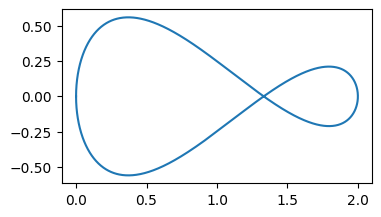

In [5]:
t = np.linspace(0, 2*np.pi, 2001)
a = 0.750996
x = 1 - np.cos(t)
y = np.sin(t)*(1 - a + a*np.cos(t))
alpha = x + 1j*y
plt.figure(figsize=(4,3))
plt.gca().set_aspect('equal')
#plt.text(0.25, 0., rf'$\theta_4={theta_4:.4f}$')
plt.plot(x, y)

Решение уравнения $\theta_4=0$ действительно существует, это  $a = a_{opt} =0.750996$. Код ниже находит это значение. Рисунок выше построен для этого значения.

In [6]:
def theta_2(a):
    def integrand(t):
        x = 1 - np.cos(t)
        y = np.sin(t)*(1 - a + a*np.cos(t))
        vx = np.sin(t)
        return 2*y*vx
    return quad(integrand, 0, 2*np.pi)[0]

def theta_4(a):
    def integrand(t):
        x = 1 - np.cos(t)
        y = np.sin(t)*(1 - a + a*np.cos(t))
        vx = np.sin(t)
        return (x**2 + y**2)*y*vx
    return quad(integrand, 0, 2*np.pi)[0]

In [7]:
a_opt = fsolve(theta_4, 0.76)[0]
print(f'a_opt = {a_opt}')
theta_ratio = theta_2(a_opt)/theta_2(0)
print(f'theta_2 = {theta_ratio}')

a_opt = 0.7509960628023407
theta_2 = 0.24900393719765934


Импульс, соответствующий этой фазовой траектории, может быть найден из уравнения 
$$
f \propto i\frac{d\alpha}{dt}.
$$
$$
f(t) = f_{max}[e^{-it} - a(\cos{t} - \cos{2t})], \quad t \in [0, 2\pi].
$$
где $f_{max}$ находится из условия $\theta_2 = \pi/4$. При $a=0$ $f_{max} = \pi$. При нашем значении $a = a_{opt}$ значение $f_{max}$ равно $\approx 2\pi$. Импульс соответствует специально модулированному полихроматическому импульсу, где пара компонент отстроены от сайдбендов, как обычно, а ещё пара компонент светит точно в сайдбенды.

Для проверки "дееспособности" этих импульсов нужно провести численное моделирование. 

Мы симулируем исходный гамильтониан для различных проекций $\hat{S}_x$ и находим фазу, набегающую на начальном состоянии. Для идеального МС-гейта она должна быть равна 
$$
\phi = \frac{\pi S_x^2}{2}.
$$
Мы будем вычислять поправку $\Delta\phi$ к этой фазе.

На графиках ниже представлены зависимости $\Delta\phi$ от проекции  $m_x$ для прямоугольного и модифицированного импульса. 

In [8]:
def ion_ham(f_arr, t_arr, eta, m_x, N_cutoff):
    a = destroy(N_cutoff)
    A = (1 - eta**2/2)*a - eta**2/2*a.dag()*a*a
    return QobjEvo([[A,        m_x*np.conj(f_arr)],
                    [A.dag(), m_x*f_arr]], tlist=t_arr)

In [9]:
def smart_f(t, a):
    return np.exp(-1j*t) - a*(np.cos(t) - np.cos(2*t))

In [10]:
def phase_residuals(mx_arr, t_arr, f_max, a, eta, N_cutoff):
    phase_arr = []
    f_arr = f_max*smart_f(t_arr, a)
    psi0 = fock(N_cutoff, 0)
    for mx in mx_arr:
        ham = ion_ham(f_arr, t_arr, eta, mx, N_cutoff)
        result = sesolve(ham, psi0, t_arr, options={'store_states' : False, 
                                                'store_final_state': True})
        phase = result.final_state[0,0]*np.exp(1j*np.pi/2*mx**2)
        phase_arr.append(phase)
    
    phase_arr = np.array(phase_arr)
    return phase_arr

In [19]:
t_gate = 2*np.pi
t_arr = np.linspace(0, t_gate, 1001)
f_max = 1/2/math.sqrt(theta_ratio)
a = a_opt*1.00

N_cutoff = 600
eta = 0.02
#m_x = n_ions/2

mx_arr = np.arange(-10, 11)
phase_arr_0 = phase_residuals(mx_arr, t_arr, 0.5,   0, eta, N_cutoff)
phase_arr   = phase_residuals(mx_arr, t_arr, f_max, a_opt, eta, N_cutoff)

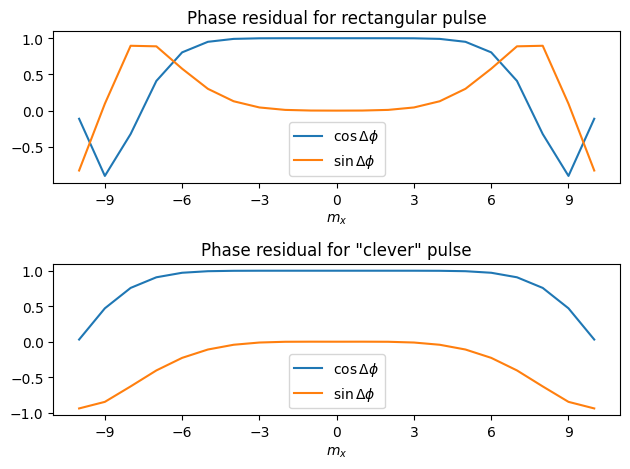

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1)

ax1.set_title('Phase residual for rectangular pulse')
ax1.plot(mx_arr, np.real(phase_arr_0), label='$\cos{\Delta\phi}$')
ax1.plot(mx_arr, np.imag(phase_arr_0), label='$\sin{\Delta\phi}$')
ax1.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
ax1.set_xlabel('$m_x$')
ax1.legend()

ax2.set_title('Phase residual for "clever" pulse')
ax2.plot(mx_arr, np.real(phase_arr), label='$\cos{\Delta\phi}$')
ax2.plot(mx_arr, np.imag(phase_arr), label='$\sin{\Delta\phi}$')
ax2.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
ax2.set_xlabel('$m_x$')
ax2.legend()

plt.tight_layout()
plt.show()